## Machine Learning

🚀 Email Phishing Classification: Synthetic Data Substitution Analysis
🔴 MALICIOUS-ONLY SYNTHETIC DATA VERSION
Research Question 2: What is the optimal ratio of real vs synthetic data for training?
⚠️  Note: Synthetic data contains ONLY malicious samples
Synthetic data ratios tested: 0%, 10%, 20%, 30%, 40%, 50%, 60%, 70%, 80%, 90%, 100%
Fixed training size: 2K samples
Classifiers: SVM, Random Forest, XGBoost
📂 Data Files:
   Real Training: ../raw/email_phishing_CEAS-08_train.csv.gz
   Testing: ../raw/email_phishing_CEAS-08_test.csv.gz
   Synthetic (Malicious-Only): ../data/seeds-augment/email_phishing_CEAS-08_train_augment_malicious_100_10.csv.gz

🎯 Experimental Setup:
   Synthetic ratios: ['0%', '10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%']
   Fixed training size: 1,000 samples
   Cross-validation: 5-fold
   Random state: 42

📊 LOADING DATASETS

📥 Loading real training data from: ../raw/email_phishing_CEAS-08_train.csv.gz
   ✅ Loaded successfully!
   Shape: (20

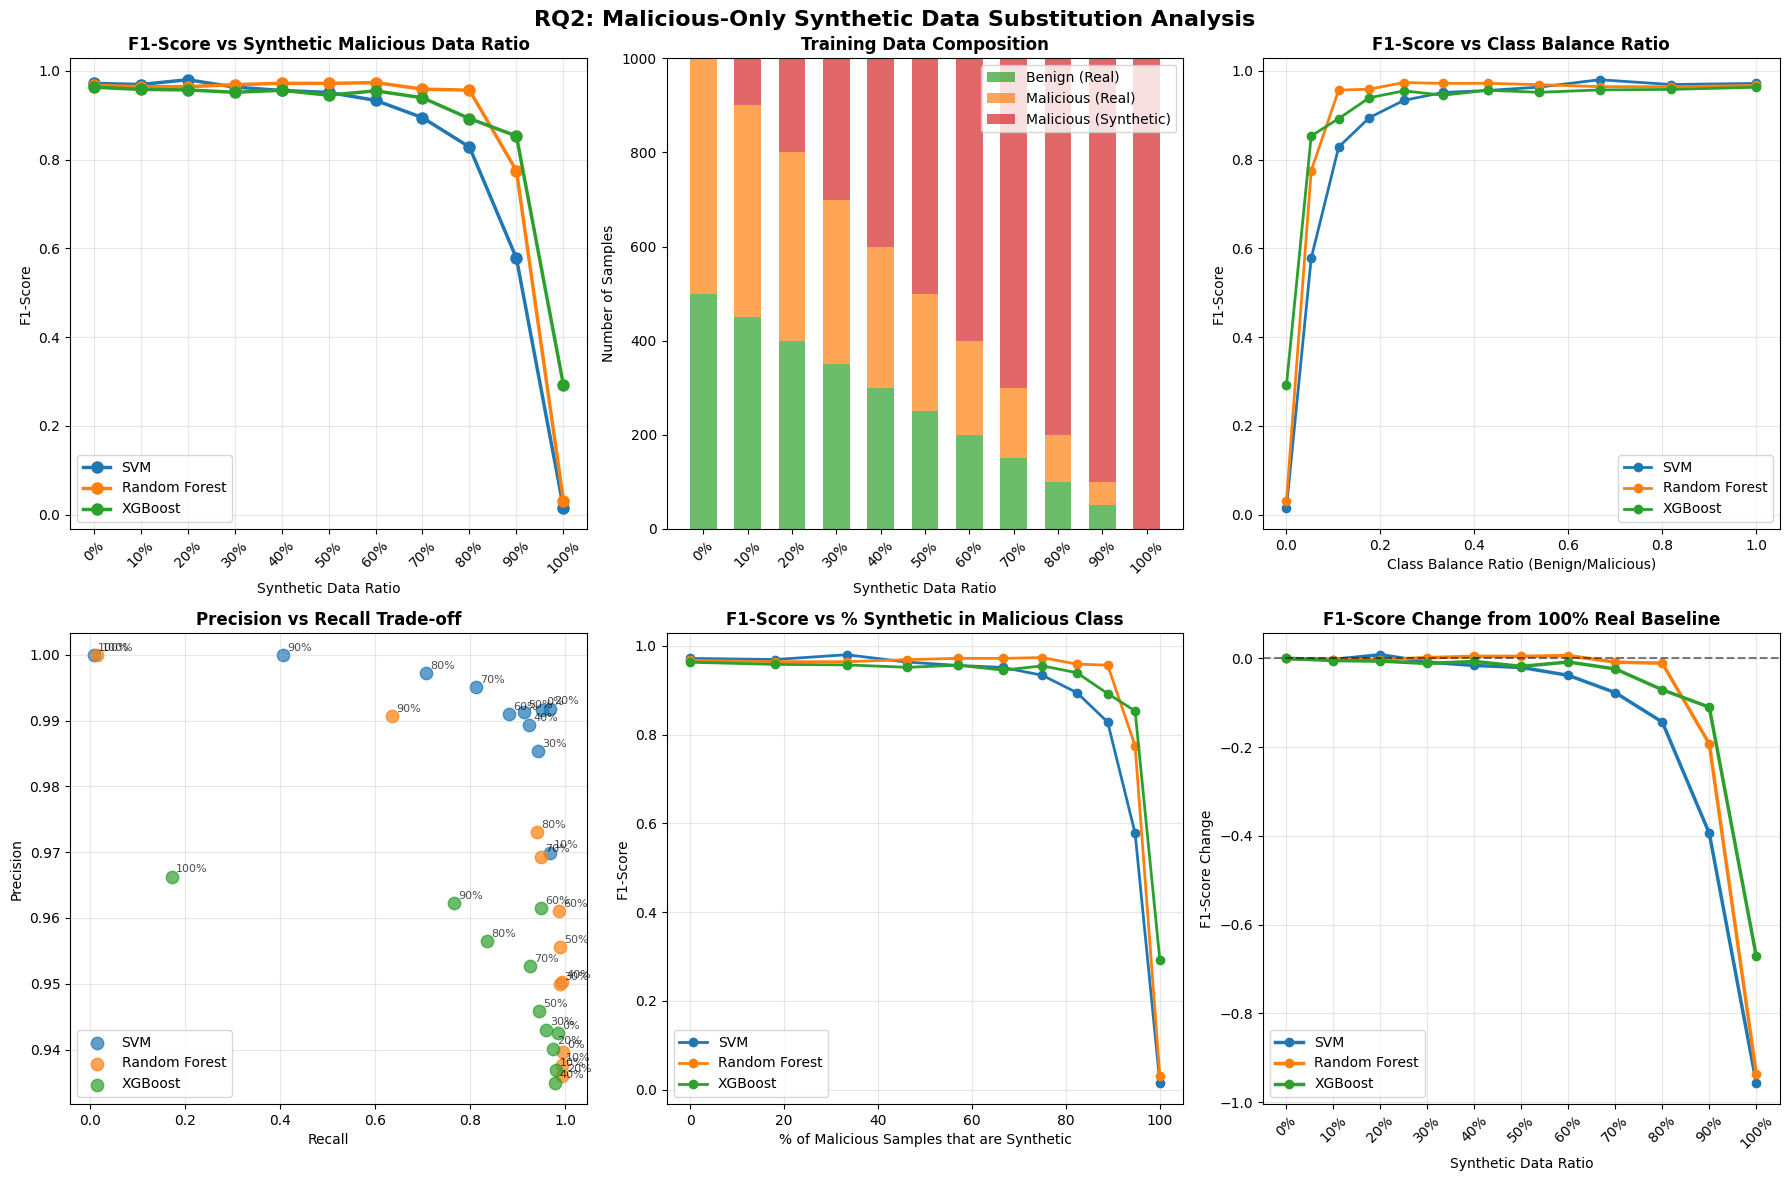

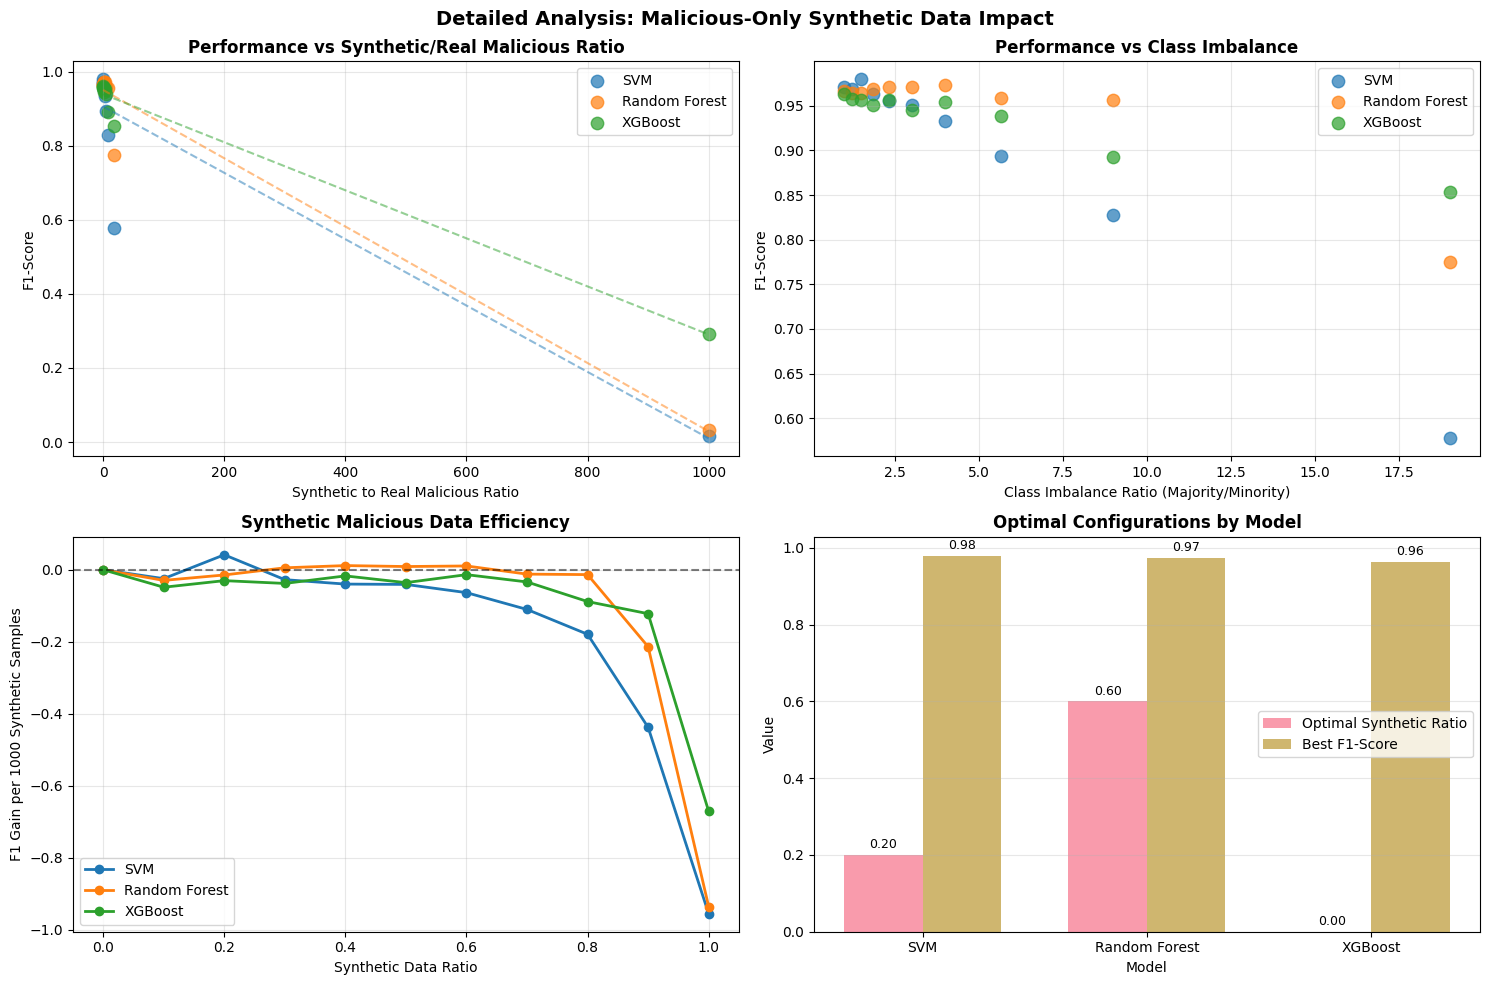


🔍 KEY FINDINGS - MALICIOUS-ONLY SYNTHETIC DATA SUBSTITUTION

🏆 BEST OVERALL PERFORMANCE:
   Model: SVM
   Synthetic ratio: 20%
   F1-Score: 0.980
   Data composition:
      Benign: 400
      Real malicious: 400
      Synthetic malicious: 200
      Total malicious: 600

⚖️  PURE REAL vs PURE SYNTHETIC MALICIOUS COMPARISON:
   SVM:
      100% Real malicious: 0.971
      100% Synthetic malicious: 0.016
      Difference: -0.956 (Real Better)
   Random Forest:
      100% Real malicious: 0.967
      100% Synthetic malicious: 0.031
      Difference: -0.935 (Real Better)
   XGBoost:
      100% Real malicious: 0.963
      100% Synthetic malicious: 0.292
      Difference: -0.671 (Real Better)

⚖️  CLASS BALANCE IMPACT:
   Synthetic Ratio -> Class Balance (Benign/Malicious) -> Avg F1
   0% -> 1.00 -> 0.967
   10% -> 0.82 -> 0.964
   20% -> 0.67 -> 0.967
   30% -> 0.54 -> 0.961
   40% -> 0.43 -> 0.961
   50% -> 0.33 -> 0.956
   60% -> 0.25 -> 0.954
   70% -> 0.18 -> 0.931
   80% -> 0.11 -> 0.892


In [1]:
# RQ2: Synthetic Data Substitution Analysis - Modified for Malicious-Only Synthetic Data
# Research Question 2: What is the optimal ratio of real vs synthetic data for training?

import pandas as pd
import numpy as np
import gzip
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                           precision_score, recall_score, f1_score, roc_auc_score, roc_curve)
import xgboost as xgb

# Visualization
plt.style.use('default')
sns.set_palette("husl")

print("🚀 Email Phishing Classification: Synthetic Data Substitution Analysis")
print("🔴 MALICIOUS-ONLY SYNTHETIC DATA VERSION")
print("=" * 80)
print("Research Question 2: What is the optimal ratio of real vs synthetic data for training?")
print("⚠️  Note: Synthetic data contains ONLY malicious samples")
print("Synthetic data ratios tested: 0%, 10%, 20%, 30%, 40%, 50%, 60%, 70%, 80%, 90%, 100%")
print("Fixed training size: 2K samples")
print("Classifiers: SVM, Random Forest, XGBoost")
print("=" * 80)

# =============================================================================
# CONFIGURATION
# =============================================================================

# File paths
TRAIN_FILE = "../raw/email_phishing_CEAS-08_train.csv.gz"
TEST_FILE = "../raw/email_phishing_CEAS-08_test.csv.gz"
SYNTHETIC_FILE = "../data/seeds-augment/email_phishing_CEAS-08_train_augment_malicious_100_10.csv.gz"

# Experimental configuration
SYNTHETIC_RATIOS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]  # 0% to 100%
FIXED_TRAINING_SIZE = 1000  # Keep training size constant
RANDOM_STATE = 42
CV_FOLDS = 5

# Text preprocessing parameters
MAX_FEATURES = 5000
MIN_DF = 2
MAX_DF = 0.95
NGRAM_RANGE = (1, 2)

print(f"📂 Data Files:")
print(f"   Real Training: {TRAIN_FILE}")
print(f"   Testing: {TEST_FILE}")
print(f"   Synthetic (Malicious-Only): {SYNTHETIC_FILE}")
print(f"\n🎯 Experimental Setup:")
print(f"   Synthetic ratios: {[f'{r:.0%}' for r in SYNTHETIC_RATIOS]}")
print(f"   Fixed training size: {FIXED_TRAINING_SIZE:,} samples")
print(f"   Cross-validation: {CV_FOLDS}-fold")
print(f"   Random state: {RANDOM_STATE}")

# =============================================================================
# 1. DATA LOADING AND PREPROCESSING
# =============================================================================

def load_compressed_data(file_path, description="data"):
    """Load compressed CSV data with error handling."""
    print(f"\n📥 Loading {description} from: {file_path}")
    
    try:
        with gzip.open(file_path, 'rt', encoding='utf-8') as f:
            df = pd.read_csv(f)
        
        print(f"   ✅ Loaded successfully!")
        print(f"   Shape: {df.shape}")
        print(f"   Columns: {list(df.columns)}")
        
        # Check label distribution
        if 'label' in df.columns:
            label_counts = df['label'].value_counts().sort_index()
            print(f"   Label distribution:")
            for label in sorted(label_counts.index):
                print(f"      Label {label}: {label_counts[label]:,} ({label_counts[label]/len(df)*100:.1f}%)")
        
        return df
        
    except Exception as e:
        print(f"   ❌ Error loading {description}: {e}")
        raise

def preprocess_text(df):
    """Combine subject and body into single text feature."""
    print(f"\n🔤 Preprocessing text features for {len(df)} samples...")
    
    # Handle missing values
    df['subject'] = df['subject'].fillna('')
    df['body'] = df['body'].fillna('')
    
    # Combine subject and body
    df['combined_text'] = df['subject'] + ' ' + df['body']
    
    # Remove empty texts
    df = df[df['combined_text'].str.strip() != '']
    
    print(f"   ✅ Text preprocessing completed")
    print(f"   Final samples: {len(df):,}")
    
    return df

# Load all datasets
print("\n" + "="*60)
print("📊 LOADING DATASETS")
print("="*60)

real_train_df = load_compressed_data(TRAIN_FILE, "real training data")
test_df = load_compressed_data(TEST_FILE, "test data")
synthetic_df = load_compressed_data(SYNTHETIC_FILE, "synthetic data")

# Preprocess all datasets
real_train_df = preprocess_text(real_train_df.copy())
test_df = preprocess_text(test_df.copy())
synthetic_df = preprocess_text(synthetic_df.copy())

# =============================================================================
# 2. MALICIOUS-ONLY SYNTHETIC DATA VERIFICATION
# =============================================================================

def verify_malicious_only_synthetic():
    """Verify that synthetic data contains only malicious samples."""
    print("\n" + "="*60)
    print("🔍 MALICIOUS-ONLY SYNTHETIC DATA VERIFICATION")
    print("="*60)
    
    # Check synthetic data composition
    synthetic_labels = synthetic_df['label'].value_counts().sort_index()
    print(f"\n📊 Synthetic Data Composition:")
    for label in sorted(synthetic_labels.index):
        print(f"   Label {label}: {synthetic_labels[label]:,} ({synthetic_labels[label]/len(synthetic_df)*100:.1f}%)")
    
    # Verify it's malicious-only
    if len(synthetic_labels) == 1 and 1 in synthetic_labels.index:
        print(f"   ✅ CONFIRMED: Synthetic data contains ONLY malicious samples")
        malicious_only = True
    elif 1 in synthetic_labels.index and synthetic_labels[1] == len(synthetic_df):
        print(f"   ✅ CONFIRMED: Synthetic data contains ONLY malicious samples")
        malicious_only = True
    else:
        print(f"   ⚠️  WARNING: Synthetic data contains mixed labels!")
        print(f"   This code is optimized for malicious-only synthetic data")
        malicious_only = False
    
    # Check real data composition for comparison
    real_labels = real_train_df['label'].value_counts().sort_index()
    print(f"\n📊 Real Training Data Composition:")
    for label in sorted(real_labels.index):
        print(f"   Label {label}: {real_labels[label]:,} ({real_labels[label]/len(real_train_df)*100:.1f}%)")
    
    return malicious_only

# Verify synthetic data composition
is_malicious_only = verify_malicious_only_synthetic()

# =============================================================================
# 3. MODIFIED MIXED DATASET CREATION FOR MALICIOUS-ONLY SYNTHETIC
# =============================================================================

def create_mixed_dataset_malicious_only(real_df, synthetic_df, synthetic_ratio, total_size=FIXED_TRAINING_SIZE, random_state=42):
    """
    Create a mixed dataset with malicious-only synthetic data.
    
    Strategy:
    1. Calculate how many synthetic malicious samples to add
    2. Reduce real malicious samples accordingly to maintain balance
    3. Keep benign samples from real data only
    4. Ensure total size and reasonable class balance
    
    Parameters:
    - real_df: Real training data DataFrame (mixed labels)
    - synthetic_df: Synthetic data DataFrame (malicious-only)
    - synthetic_ratio: Ratio of synthetic data (0.0 to 1.0)
    - total_size: Total desired size of mixed dataset
    - random_state: Random seed for reproducibility
    
    Returns:
    - Mixed DataFrame with specified synthetic ratio
    """
    print(f"\n🎯 Creating mixed dataset with {synthetic_ratio:.0%} synthetic malicious data...")
    
    # Separate real data by label
    real_benign = real_df[real_df['label'] == 0].copy()
    real_malicious = real_df[real_df['label'] == 1].copy()
    
    # All synthetic data is malicious
    synthetic_malicious = synthetic_df.copy()  # Already malicious-only
    
    print(f"   Available data:")
    print(f"      Real benign: {len(real_benign):,}")
    print(f"      Real malicious: {len(real_malicious):,}")
    print(f"      Synthetic malicious: {len(synthetic_malicious):,}")
    
    # Calculate target counts
    target_synthetic_malicious = int(total_size * synthetic_ratio)
    remaining_size = total_size - target_synthetic_malicious
    
    # Strategy: Keep roughly 50-50 class balance
    target_benign = remaining_size // 2
    target_real_malicious = remaining_size - target_benign
    
    print(f"\n   Target composition:")
    print(f"      Benign (from real): {target_benign:,}")
    print(f"      Malicious from real: {target_real_malicious:,}")
    print(f"      Malicious from synthetic: {target_synthetic_malicious:,}")
    print(f"      Total malicious: {target_real_malicious + target_synthetic_malicious:,}")
    print(f"      Overall balance: {target_benign:,} benign vs {target_real_malicious + target_synthetic_malicious:,} malicious")
    
    np.random.seed(random_state)
    mixed_samples = []
    actual_counts = {'benign': 0, 'real_malicious': 0, 'synthetic_malicious': 0}
    
    # Add benign samples (only from real data)
    if target_benign > 0:
        actual_benign = min(target_benign, len(real_benign))
        if actual_benign > 0:
            sampled_benign = real_benign.sample(n=actual_benign, random_state=random_state)
            mixed_samples.append(sampled_benign)
            actual_counts['benign'] = actual_benign
            print(f"      ✅ Added {actual_benign:,} benign samples (real)")
    
    # Add real malicious samples
    if target_real_malicious > 0:
        actual_real_malicious = min(target_real_malicious, len(real_malicious))
        if actual_real_malicious > 0:
            sampled_real_malicious = real_malicious.sample(n=actual_real_malicious, random_state=random_state+1)
            mixed_samples.append(sampled_real_malicious)
            actual_counts['real_malicious'] = actual_real_malicious
            print(f"      ✅ Added {actual_real_malicious:,} malicious samples (real)")
    
    # Add synthetic malicious samples
    if target_synthetic_malicious > 0:
        actual_synthetic_malicious = min(target_synthetic_malicious, len(synthetic_malicious))
        if actual_synthetic_malicious > 0:
            sampled_synthetic_malicious = synthetic_malicious.sample(n=actual_synthetic_malicious, random_state=random_state+2)
            mixed_samples.append(sampled_synthetic_malicious)
            actual_counts['synthetic_malicious'] = actual_synthetic_malicious
            print(f"      ✅ Added {actual_synthetic_malicious:,} malicious samples (synthetic)")
    
    # Combine all samples
    if mixed_samples:
        mixed_df = pd.concat(mixed_samples, ignore_index=True)
        
        # Shuffle the combined dataset
        mixed_df = mixed_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
        
        # Calculate final statistics
        final_size = len(mixed_df)
        final_labels = mixed_df['label'].value_counts().sort_index()
        total_malicious = actual_counts['real_malicious'] + actual_counts['synthetic_malicious']
        
        # Calculate actual ratios
        synthetic_ratio_actual = actual_counts['synthetic_malicious'] / final_size if final_size > 0 else 0
        malicious_ratio_actual = total_malicious / final_size if final_size > 0 else 0
        
        print(f"\n   ✅ Final mixed dataset: {final_size:,} samples")
        print(f"      Benign: {actual_counts['benign']:,} ({actual_counts['benign']/final_size:.1%})")
        print(f"      Malicious: {total_malicious:,} ({malicious_ratio_actual:.1%})")
        print(f"         - From real: {actual_counts['real_malicious']:,}")
        print(f"         - From synthetic: {actual_counts['synthetic_malicious']:,}")
        print(f"      Synthetic ratio: {synthetic_ratio_actual:.1%} of total dataset")
        print(f"      Synthetic in malicious: {actual_counts['synthetic_malicious']/total_malicious:.1%} of malicious samples" if total_malicious > 0 else "")
        
        return mixed_df, actual_counts
    else:
        raise ValueError("No samples could be created for mixed dataset")

# =============================================================================
# 4. MACHINE LEARNING MODELS (SAME AS BEFORE)
# =============================================================================

def initialize_models():
    """Initialize the three classifiers with optimized parameters."""
    models = {
        'SVM': SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            probability=True,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            eval_metric='logloss',
            verbosity=0
        )
    }
    
    print("\n🤖 Initialized ML Models:")
    for name, model in models.items():
        print(f"   ✅ {name}: {type(model).__name__}")
    
    return models

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Train model and return comprehensive evaluation metrics."""
    
    print(f"   🔄 Training {model_name}...")
    
    if model_name == 'XGBoost':
        # Handle class imbalance for XGBoost
        class_weights = len(y_train) / (2 * np.bincount(y_train))
        sample_weights = np.where(y_train == 0, class_weights[0], class_weights[1])
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'auc': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 0
    }
    
    print(f"      ✅ {model_name} trained - F1: {metrics['f1']:.3f}, AUC: {metrics['auc']:.3f}")
    
    return metrics, y_pred, y_pred_proba

# =============================================================================
# 5. MAIN EXPERIMENT: RQ2 - SYNTHETIC DATA SUBSTITUTION (MALICIOUS-ONLY)
# =============================================================================

def run_synthetic_substitution_experiment_malicious_only():
    """Run the main experiment for RQ2 with malicious-only synthetic data."""
    
    print("\n" + "="*80)
    print("🧪 EXPERIMENT RQ2: MALICIOUS-ONLY SYNTHETIC DATA SUBSTITUTION")
    print("="*80)
    
    # Initialize models
    models = initialize_models()
    
    # Initialize results storage
    results = {
        'synthetic_ratio': [],
        'model': [],
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'auc': [],
        'benign_samples': [],
        'real_malicious_samples': [],
        'synthetic_malicious_samples': [],
        'total_malicious_samples': [],
        'class_balance_ratio': []  # benign / malicious
    }
    
    # Store detailed results
    detailed_results = {}
    
    # Text vectorization
    print(f"\n📝 Setting up TF-IDF vectorization...")
    
    # Combine real and synthetic data for fitting vectorizer
    all_training_text = pd.concat([
        real_train_df['combined_text'],
        synthetic_df['combined_text']
    ], ignore_index=True)
    
    vectorizer = TfidfVectorizer(
        max_features=MAX_FEATURES,
        min_df=MIN_DF,
        max_df=MAX_DF,
        ngram_range=NGRAM_RANGE,
        stop_words='english'
    )
    
    # Fit vectorizer on all training data
    vectorizer.fit(all_training_text)
    
    # Vectorize test data (constant across all experiments)
    X_test = vectorizer.transform(test_df['combined_text'])
    y_test = test_df['label'].values
    
    print(f"   ✅ Vectorizer fitted - Features: {X_test.shape[1]:,}")
    print(f"   Test set: {X_test.shape[0]:,} samples")
    
    # Run experiments for each synthetic ratio
    for i, ratio in enumerate(SYNTHETIC_RATIOS):
        print(f"\n{'='*60}")
        print(f"📊 EXPERIMENT {i+1}/{len(SYNTHETIC_RATIOS)}: {ratio:.0%} SYNTHETIC MALICIOUS DATA")
        print(f"{'='*60}")
        
        # Create mixed training dataset with malicious-only synthetic data
        mixed_train, actual_counts = create_mixed_dataset_malicious_only(
            real_train_df, synthetic_df, ratio, 
            FIXED_TRAINING_SIZE, RANDOM_STATE + i
        )
        
        # Vectorize training data
        X_train = vectorizer.transform(mixed_train['combined_text'])
        y_train = mixed_train['label'].values
        
        print(f"\n   Training set: {X_train.shape[0]:,} samples, {X_train.shape[1]:,} features")
        
        # Calculate class balance ratio
        total_malicious = actual_counts['real_malicious'] + actual_counts['synthetic_malicious']
        class_balance_ratio = actual_counts['benign'] / total_malicious if total_malicious > 0 else 0
        
        print(f"   Class balance: {actual_counts['benign']:,} benign / {total_malicious:,} malicious (ratio: {class_balance_ratio:.2f})")
        
        # Store experiment details
        detailed_results[ratio] = {
            'train_size': len(y_train),
            'actual_counts': actual_counts,
            'class_balance_ratio': class_balance_ratio,
            'models': {}
        }
        
        # Train and evaluate each model
        for model_name, _ in models.items():
            print(f"\n   🤖 Evaluating {model_name}...")
            
            # Create fresh model instance for each experiment
            if model_name == 'SVM':
                fresh_model = SVC(
                    kernel='rbf', C=1.0, gamma='scale', probability=True,
                    random_state=RANDOM_STATE, class_weight='balanced'
                )
            elif model_name == 'Random Forest':
                fresh_model = RandomForestClassifier(
                    n_estimators=100, max_depth=20, min_samples_split=5,
                    min_samples_leaf=2, random_state=RANDOM_STATE, class_weight='balanced'
                )
            else:  # XGBoost
                fresh_model = xgb.XGBClassifier(
                    n_estimators=100, max_depth=6, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                    eval_metric='logloss', verbosity=0
                )
            
            # Train and evaluate
            metrics, y_pred, y_pred_proba = train_and_evaluate_model(
                fresh_model, X_train, y_train, X_test, y_test, model_name
            )
            
            # Store results
            results['synthetic_ratio'].append(ratio)
            results['model'].append(model_name)
            results['accuracy'].append(metrics['accuracy'])
            results['precision'].append(metrics['precision'])
            results['recall'].append(metrics['recall'])
            results['f1'].append(metrics['f1'])
            results['auc'].append(metrics['auc'])
            results['benign_samples'].append(actual_counts['benign'])
            results['real_malicious_samples'].append(actual_counts['real_malicious'])
            results['synthetic_malicious_samples'].append(actual_counts['synthetic_malicious'])
            results['total_malicious_samples'].append(total_malicious)
            results['class_balance_ratio'].append(class_balance_ratio)
            
            # Store detailed results
            detailed_results[ratio]['models'][model_name] = {
                'metrics': metrics,
                'predictions': y_pred,
                'probabilities': y_pred_proba,
                'confusion_matrix': confusion_matrix(y_test, y_pred)
            }
            
            print(f"      📈 Results - Acc: {metrics['accuracy']:.3f}, "
                  f"Prec: {metrics['precision']:.3f}, Rec: {metrics['recall']:.3f}, "
                  f"F1: {metrics['f1']:.3f}, AUC: {metrics['auc']:.3f}")
    
    return pd.DataFrame(results), detailed_results

# Run the main experiment
results_df, detailed_results = run_synthetic_substitution_experiment_malicious_only()

# =============================================================================
# 6. RESULTS ANALYSIS FOR MALICIOUS-ONLY SYNTHETIC DATA
# =============================================================================

print("\n" + "="*80)
print("📊 RESULTS ANALYSIS - RQ2: MALICIOUS-ONLY SYNTHETIC DATA SUBSTITUTION")
print("="*80)

# Display summary table
print("\n📋 Summary Results Table:")
print("-" * 120)

# Create enhanced summary table
summary_table = results_df.pivot_table(
    index='synthetic_ratio', 
    columns='model', 
    values=['f1', 'precision', 'recall', 'auc'],
    aggfunc='mean'
)

print(summary_table.round(3))

# Additional analysis specific to malicious-only synthetic data
print("\n📊 Data Composition Analysis:")
print("-" * 80)

composition_df = results_df.groupby('synthetic_ratio').agg({
    'benign_samples': 'first',
    'real_malicious_samples': 'first', 
    'synthetic_malicious_samples': 'first',
    'total_malicious_samples': 'first',
    'class_balance_ratio': 'first'
}).round(2)

print(composition_df)

# =============================================================================
# 7. VISUALIZATION FOR MALICIOUS-ONLY SYNTHETIC DATA
# =============================================================================

def create_malicious_only_visualizations():
    """Create visualizations specific to malicious-only synthetic data."""
    
    colors = {'SVM': '#1f77b4', 'Random Forest': '#ff7f0e', 'XGBoost': '#2ca02c'}
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('RQ2: Malicious-Only Synthetic Data Substitution Analysis', 
                 fontsize=16, fontweight='bold')
    
    # 1. F1-Score vs Synthetic Ratio
    ax1 = axes[0, 0]
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        ax1.plot(model_data['synthetic_ratio'], model_data['f1'], 
               marker='o', linewidth=2.5, markersize=8, 
               label=model, color=colors[model])
    
    ax1.set_title('F1-Score vs Synthetic Malicious Data Ratio', fontweight='bold')
    ax1.set_xlabel('Synthetic Data Ratio')
    ax1.set_ylabel('F1-Score')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xticks(SYNTHETIC_RATIOS)
    ax1.set_xticklabels([f'{r:.0%}' for r in SYNTHETIC_RATIOS], rotation=45)
    
    # 2. Data Composition Stacked Bar
    ax2 = axes[0, 1]
    
    # Get unique compositions
    unique_ratios = sorted(results_df['synthetic_ratio'].unique())
    benign_counts = []
    real_mal_counts = []
    synth_mal_counts = []
    
    for ratio in unique_ratios:
        ratio_data = results_df[results_df['synthetic_ratio'] == ratio].iloc[0]
        benign_counts.append(ratio_data['benign_samples'])
        real_mal_counts.append(ratio_data['real_malicious_samples'])
        synth_mal_counts.append(ratio_data['synthetic_malicious_samples'])
    
    width = 0.6
    x = np.arange(len(unique_ratios))
    
    ax2.bar(x, benign_counts, width, label='Benign (Real)', color='#2ca02c', alpha=0.7)
    ax2.bar(x, real_mal_counts, width, bottom=benign_counts, 
           label='Malicious (Real)', color='#ff7f0e', alpha=0.7)
    
    bottom_synth = np.array(benign_counts) + np.array(real_mal_counts)
    ax2.bar(x, synth_mal_counts, width, bottom=bottom_synth,
           label='Malicious (Synthetic)', color='#d62728', alpha=0.7)
    
    ax2.set_title('Training Data Composition', fontweight='bold')
    ax2.set_xlabel('Synthetic Data Ratio')
    ax2.set_ylabel('Number of Samples')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'{r:.0%}' for r in unique_ratios], rotation=45)
    ax2.legend()
    
    # 3. Class Balance Impact
    ax3 = axes[0, 2]
    
    # Plot how class balance changes
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        ax3.plot(model_data['class_balance_ratio'], model_data['f1'], 
               marker='o', linewidth=2, markersize=6, 
               label=model, color=colors[model])
    
    ax3.set_title('F1-Score vs Class Balance Ratio', fontweight='bold')
    ax3.set_xlabel('Class Balance Ratio (Benign/Malicious)')
    ax3.set_ylabel('F1-Score')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # 4. Precision vs Recall Trade-off
    ax4 = axes[1, 0]
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        ax4.scatter(model_data['recall'], model_data['precision'], 
                   label=model, color=colors[model], s=80, alpha=0.7)
        
        # Add synthetic ratio annotations
        for _, row in model_data.iterrows():
            ax4.annotate(f"{row['synthetic_ratio']:.0%}", 
                        (row['recall'], row['precision']), 
                        xytext=(3, 3), textcoords='offset points', 
                        fontsize=8, alpha=0.7)
    
    ax4.set_title('Precision vs Recall Trade-off', fontweight='bold')
    ax4.set_xlabel('Recall')
    ax4.set_ylabel('Precision')
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    # 5. Synthetic Malicious Data Impact
    ax5 = axes[1, 1]
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        
        # Calculate percentage of malicious samples that are synthetic
        synth_in_malicious_pct = model_data['synthetic_malicious_samples'] / model_data['total_malicious_samples'] * 100
        
        ax5.plot(synth_in_malicious_pct, model_data['f1'], 
               marker='o', linewidth=2, markersize=6, 
               label=model, color=colors[model])
    
    ax5.set_title('F1-Score vs % Synthetic in Malicious Class', fontweight='bold')
    ax5.set_xlabel('% of Malicious Samples that are Synthetic')
    ax5.set_ylabel('F1-Score')
    ax5.grid(True, alpha=0.3)
    ax5.legend()
    
    # 6. Performance Change from Baseline
    ax6 = axes[1, 2]
    
    # Calculate performance change from 0% synthetic baseline
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_ratio')
        baseline_f1 = model_data.iloc[0]['f1']  # 0% synthetic
        
        performance_changes = []
        for _, row in model_data.iterrows():
            change = row['f1'] - baseline_f1
            performance_changes.append(change)
        
        ax6.plot(model_data['synthetic_ratio'], performance_changes, 
               marker='o', linewidth=2.5, markersize=6, 
               label=model, color=colors[model])
    
    ax6.set_title('F1-Score Change from 100% Real Baseline', fontweight='bold')
    ax6.set_xlabel('Synthetic Data Ratio')
    ax6.set_ylabel('F1-Score Change')
    ax6.grid(True, alpha=0.3)
    ax6.legend()
    ax6.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax6.set_xticks(SYNTHETIC_RATIOS)
    ax6.set_xticklabels([f'{r:.0%}' for r in SYNTHETIC_RATIOS], rotation=45)
    
    plt.tight_layout()
    plt.show()

def create_malicious_only_detailed_analysis():
    """Create detailed analysis specific to malicious-only synthetic data."""
    
    colors = {'SVM': '#1f77b4', 'Random Forest': '#ff7f0e', 'XGBoost': '#2ca02c'}
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Detailed Analysis: Malicious-Only Synthetic Data Impact', fontsize=14, fontweight='bold')
    
    # 1. Real vs Synthetic Malicious Performance
    ax1 = axes[0, 0]
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        
        # Calculate the ratio of synthetic to real malicious samples
        synth_to_real_ratio = model_data['synthetic_malicious_samples'] / (model_data['real_malicious_samples'] + 1)  # +1 to avoid division by zero
        
        ax1.scatter(synth_to_real_ratio, model_data['f1'], 
                   label=model, color=colors[model], s=80, alpha=0.7)
        
        # Add trend line
        z = np.polyfit(synth_to_real_ratio, model_data['f1'], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(synth_to_real_ratio.min(), synth_to_real_ratio.max(), 100)
        ax1.plot(x_trend, p(x_trend), color=colors[model], linestyle='--', alpha=0.5)
    
    ax1.set_title('Performance vs Synthetic/Real Malicious Ratio', fontweight='bold')
    ax1.set_xlabel('Synthetic to Real Malicious Ratio')
    ax1.set_ylabel('F1-Score')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # 2. Class Imbalance Impact
    ax2 = axes[0, 1]
    
    # Calculate imbalance ratio (majority/minority class)
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        
        imbalance_ratios = []
        for _, row in model_data.iterrows():
            benign = row['benign_samples']
            malicious = row['total_malicious_samples']
            imbalance_ratio = max(benign, malicious) / min(benign, malicious) if min(benign, malicious) > 0 else float('inf')
            imbalance_ratios.append(imbalance_ratio)
        
        # Filter out infinite values
        valid_indices = [i for i, ratio in enumerate(imbalance_ratios) if ratio != float('inf')]
        valid_ratios = [imbalance_ratios[i] for i in valid_indices]
        valid_f1s = [model_data.iloc[i]['f1'] for i in valid_indices]
        
        if valid_ratios:
            ax2.scatter(valid_ratios, valid_f1s, 
                       label=model, color=colors[model], s=80, alpha=0.7)
    
    ax2.set_title('Performance vs Class Imbalance', fontweight='bold')
    ax2.set_xlabel('Class Imbalance Ratio (Majority/Minority)')
    ax2.set_ylabel('F1-Score')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # 3. Synthetic Data Efficiency for Malicious Class
    ax3 = axes[1, 0]
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_ratio')
        baseline_f1 = model_data.iloc[0]['f1']  # 0% synthetic baseline
        
        efficiency_data = []
        for _, row in model_data.iterrows():
            if row['synthetic_malicious_samples'] > 0:
                performance_gain = row['f1'] - baseline_f1
                efficiency = performance_gain / row['synthetic_malicious_samples'] * 1000  # Per 1000 synthetic samples
                efficiency_data.append(efficiency)
            else:
                efficiency_data.append(0)
        
        ax3.plot(model_data['synthetic_ratio'], efficiency_data, 
               marker='o', linewidth=2, markersize=6, 
               label=model, color=colors[model])
    
    ax3.set_title('Synthetic Malicious Data Efficiency', fontweight='bold')
    ax3.set_xlabel('Synthetic Data Ratio')
    ax3.set_ylabel('F1 Gain per 1000 Synthetic Samples')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # 4. Optimal Ratios Summary
    ax4 = axes[1, 1]
    
    # Find optimal ratios and their performance
    optimal_data = []
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        best_idx = model_data['f1'].idxmax()
        best_row = model_data.loc[best_idx]
        
        optimal_data.append({
            'model': model,
            'optimal_ratio': best_row['synthetic_ratio'],
            'best_f1': best_row['f1'],
            'synthetic_malicious': best_row['synthetic_malicious_samples'],
            'real_malicious': best_row['real_malicious_samples']
        })
    
    optimal_df = pd.DataFrame(optimal_data)
    
    # Create grouped bar chart
    x = np.arange(len(optimal_df))
    width = 0.35
    
    bars1 = ax4.bar(x - width/2, optimal_df['optimal_ratio'], width, 
                   label='Optimal Synthetic Ratio', alpha=0.7)
    bars2 = ax4.bar(x + width/2, optimal_df['best_f1'], width, 
                   label='Best F1-Score', alpha=0.7)
    
    ax4.set_title('Optimal Configurations by Model', fontweight='bold')
    ax4.set_xlabel('Model')
    ax4.set_ylabel('Value')
    ax4.set_xticks(x)
    ax4.set_xticklabels(optimal_df['model'])
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Create visualizations
create_malicious_only_visualizations()
create_malicious_only_detailed_analysis()

# =============================================================================
# 8. KEY FINDINGS FOR MALICIOUS-ONLY SYNTHETIC DATA
# =============================================================================

def analyze_malicious_only_findings():
    """Analyze key findings specific to malicious-only synthetic data."""
    
    print("\n" + "="*80)
    print("🔍 KEY FINDINGS - MALICIOUS-ONLY SYNTHETIC DATA SUBSTITUTION")
    print("="*80)
    
    # 1. Best performing configuration
    best_overall = results_df.loc[results_df['f1'].idxmax()]
    print(f"\n🏆 BEST OVERALL PERFORMANCE:")
    print(f"   Model: {best_overall['model']}")
    print(f"   Synthetic ratio: {best_overall['synthetic_ratio']:.0%}")
    print(f"   F1-Score: {best_overall['f1']:.3f}")
    print(f"   Data composition:")
    print(f"      Benign: {best_overall['benign_samples']:,}")
    print(f"      Real malicious: {best_overall['real_malicious_samples']:,}")
    print(f"      Synthetic malicious: {best_overall['synthetic_malicious_samples']:,}")
    print(f"      Total malicious: {best_overall['total_malicious_samples']:,}")
    
    # 2. Pure real vs pure synthetic malicious comparison
    print(f"\n⚖️  PURE REAL vs PURE SYNTHETIC MALICIOUS COMPARISON:")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_ratio')
        pure_real_f1 = model_data.iloc[0]['f1']  # 0% synthetic
        pure_synthetic_f1 = model_data.iloc[-1]['f1']  # 100% synthetic
        difference = pure_synthetic_f1 - pure_real_f1
        
        comparison = "Synthetic Better" if difference > 0 else "Real Better" if difference < 0 else "Equal"
        print(f"   {model}:")
        print(f"      100% Real malicious: {pure_real_f1:.3f}")
        print(f"      100% Synthetic malicious: {pure_synthetic_f1:.3f}")
        print(f"      Difference: {difference:+.3f} ({comparison})")
    
    # 3. Impact of synthetic malicious data on class balance
    print(f"\n⚖️  CLASS BALANCE IMPACT:")
    balance_analysis = results_df.groupby('synthetic_ratio').agg({
        'class_balance_ratio': 'first',
        'f1': 'mean'
    }).round(3)
    
    print("   Synthetic Ratio -> Class Balance (Benign/Malicious) -> Avg F1")
    for ratio, row in balance_analysis.iterrows():
        print(f"   {ratio:.0%} -> {row['class_balance_ratio']:.2f} -> {row['f1']:.3f}")
    
    # 4. Optimal synthetic malicious ratios
    print(f"\n🎯 OPTIMAL SYNTHETIC MALICIOUS RATIOS:")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        best_idx = model_data['f1'].idxmax()
        best_row = model_data.loc[best_idx]
        
        synth_in_malicious_pct = (best_row['synthetic_malicious_samples'] / 
                                 best_row['total_malicious_samples'] * 100) if best_row['total_malicious_samples'] > 0 else 0
        
        print(f"   {model}:")
        print(f"      Overall synthetic ratio: {best_row['synthetic_ratio']:.0%}")
        print(f"      Synthetic in malicious class: {synth_in_malicious_pct:.1f}%")
        print(f"      F1-Score: {best_row['f1']:.3f}")
    
    # 5. Robustness to malicious-only synthetic data
    print(f"\n🛡️  ROBUSTNESS TO MALICIOUS-ONLY SYNTHETIC DATA:")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        f1_std = model_data['f1'].std()
        f1_range = model_data['f1'].max() - model_data['f1'].min()
        
        # Calculate performance stability when adding synthetic malicious data
        baseline_f1 = model_data[model_data['synthetic_ratio'] == 0]['f1'].iloc[0]
        improvements = sum(1 for f1 in model_data['f1'] if f1 > baseline_f1)
        degradations = sum(1 for f1 in model_data['f1'] if f1 < baseline_f1)
        
        robustness = "High" if f1_std < 0.02 else "Medium" if f1_std < 0.05 else "Low"
        print(f"   {model}:")
        print(f"      Standard Deviation: {f1_std:.3f}")
        print(f"      Performance Range: {f1_range:.3f}")
        print(f"      Robustness: {robustness}")
        print(f"      Configurations improving over baseline: {improvements}/{len(model_data)}")
    
    # 6. Synthetic malicious data efficiency
    print(f"\n📈 SYNTHETIC MALICIOUS DATA EFFICIENCY:")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_ratio')
        baseline_f1 = model_data.iloc[0]['f1']
        
        best_efficiency = -float('inf')
        best_efficiency_ratio = 0
        best_efficiency_gain = 0
        
        for _, row in model_data.iterrows():
            if row['synthetic_malicious_samples'] > 0:
                performance_gain = row['f1'] - baseline_f1
                efficiency = performance_gain / row['synthetic_malicious_samples'] * 1000  # per 1000 samples
                
                if efficiency > best_efficiency:
                    best_efficiency = efficiency
                    best_efficiency_ratio = row['synthetic_ratio']
                    best_efficiency_gain = performance_gain
        
        print(f"   {model}:")
        print(f"      Most efficient ratio: {best_efficiency_ratio:.0%}")
        print(f"      Efficiency: {best_efficiency:.3f} F1-gain per 1000 synthetic malicious samples")
        print(f"      Performance gain: {best_efficiency_gain:+.3f}")
    
    # 7. Class-specific insights
    print(f"\n🔍 CLASS-SPECIFIC INSIGHTS:")
    
    # Analyze how precision and recall for each class are affected
    print("   Impact on Malicious Class Detection:")
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        baseline_precision = model_data.iloc[0]['precision']
        baseline_recall = model_data.iloc[0]['recall']
        
        best_precision = model_data['precision'].max()
        best_recall = model_data['recall'].max()
        
        print(f"   {model}:")
        print(f"      Precision improvement: {best_precision - baseline_precision:+.3f}")
        print(f"      Recall improvement: {best_recall - baseline_recall:+.3f}")
    
    # 8. Practical recommendations for malicious-only synthetic data
    print(f"\n💡 PRACTICAL RECOMMENDATIONS FOR MALICIOUS-ONLY SYNTHETIC DATA:")
    
    # Find overall best strategy
    avg_performance_by_ratio = results_df.groupby('synthetic_ratio')['f1'].mean().sort_values(ascending=False)
    best_overall_ratio = avg_performance_by_ratio.index[0]
    best_overall_avg_f1 = avg_performance_by_ratio.iloc[0]
    
    print(f"   🎯 RECOMMENDED STRATEGY:")
    print(f"      Optimal synthetic ratio: {best_overall_ratio:.0%}")
    print(f"      Expected average F1-Score: {best_overall_avg_f1:.3f}")
    
    # Calculate the actual composition at optimal ratio
    optimal_composition = results_df[results_df['synthetic_ratio'] == best_overall_ratio].iloc[0]
    total_samples = optimal_composition['benign_samples'] + optimal_composition['total_malicious_samples']
    
    print(f"      Recommended training composition:")
    print(f"         Benign samples: {optimal_composition['benign_samples']:,} ({optimal_composition['benign_samples']/total_samples:.1%})")
    print(f"         Real malicious: {optimal_composition['real_malicious_samples']:,}")
    print(f"         Synthetic malicious: {optimal_composition['synthetic_malicious_samples']:,}")
    print(f"         Total malicious: {optimal_composition['total_malicious_samples']:,} ({optimal_composition['total_malicious_samples']/total_samples:.1%})")
    
    # Cost-benefit analysis
    baseline_avg = results_df[results_df['synthetic_ratio'] == 0]['f1'].mean()
    improvement = best_overall_avg_f1 - baseline_avg
    
    if improvement > 0.01:
        print(f"   ✅ BENEFITS: Adding {best_overall_ratio:.0%} synthetic malicious data improves performance by {improvement:.3f} F1-score")
    elif improvement < -0.01:
        print(f"   ⚠️  WARNING: Synthetic malicious data reduces performance by {abs(improvement):.3f} F1-score")
    else:
        print(f"   ➡️  NEUTRAL: Synthetic malicious data has minimal impact on performance")
    
    # Model-specific recommendations
    print(f"\n   📊 MODEL-SPECIFIC RECOMMENDATIONS:")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        best_idx = model_data['f1'].idxmax()
        best_config = model_data.loc[best_idx]
        
        baseline_f1 = model_data[model_data['synthetic_ratio'] == 0]['f1'].iloc[0]
        improvement = best_config['f1'] - baseline_f1
        
        if improvement > 0.01:
            recommendation = f"Use {best_config['synthetic_ratio']:.0%} synthetic malicious data"
        elif improvement < -0.01:
            recommendation = "Avoid synthetic malicious data, use 100% real data"
        else:
            recommendation = "Synthetic malicious data has minimal impact"
        
        print(f"      {model}: {recommendation} (improvement: {improvement:+.3f})")

# Run the analysis
analyze_malicious_only_findings()

# =============================================================================
# 9. FINAL SUMMARY FOR MALICIOUS-ONLY SYNTHETIC DATA
# =============================================================================

print(f"\n" + "="*80)
print("📝 MALICIOUS-ONLY SYNTHETIC DATA SUBSTITUTION - FINAL SUMMARY")
print("="*80)

print(f"\n🎯 RESEARCH QUESTION:")
print(f"   What is the optimal ratio of real vs synthetic data when synthetic data contains ONLY malicious samples?")

print(f"\n📊 EXPERIMENTAL DESIGN:")
print(f"   • Synthetic ratios tested: {', '.join([f'{r:.0%}' for r in SYNTHETIC_RATIOS])}")
print(f"   • Constraint: Synthetic data contains ONLY malicious samples")
print(f"   • Fixed training size: {FIXED_TRAINING_SIZE:,} samples")
print(f"   • Benign samples: Always from real data only")
print(f"   • Malicious samples: Mix of real and synthetic")
print(f"   • Models: SVM, Random Forest, XGBoost")

print(f"\n🔍 KEY INSIGHTS:")

# Summary statistics
best_overall = results_df.loc[results_df['f1'].idxmax()]
avg_performance_by_ratio = results_df.groupby('synthetic_ratio')['f1'].mean()
best_ratio = avg_performance_by_ratio.idxmax()

print(f"   1. Best overall performance: {best_overall['model']} at {best_overall['synthetic_ratio']:.0%} synthetic (F1: {best_overall['f1']:.3f})")
print(f"   2. Best average ratio across models: {best_ratio:.0%} synthetic")

# Compare pure strategies
pure_real_avg = results_df[results_df['synthetic_ratio'] == 0.0]['f1'].mean()
pure_synthetic_avg = results_df[results_df['synthetic_ratio'] == 1.0]['f1'].mean()

print(f"   3. Pure real vs pure synthetic malicious:")
print(f"      100% real: {pure_real_avg:.3f} average F1")
print(f"      100% synthetic malicious: {pure_synthetic_avg:.3f} average F1")
print(f"      Difference: {pure_synthetic_avg - pure_real_avg:+.3f}")

print(f"\n✅ EXPERIMENT COMPLETED!")
print(f"   Configurations tested: {len(results_df)}")
print(f"   Unique synthetic ratios: {len(results_df['synthetic_ratio'].unique())}")
print(f"   Models evaluated: {len(results_df['model'].unique())}")

print(f"\n🎉 MALICIOUS-ONLY SYNTHETIC DATA ANALYSIS COMPLETE!")
print(f"=" * 80)